# Does the "hikkake" false-breakout trap actually pay? 🪤
### A famous price-action pattern — inside bar, fake-out, snap-back — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Trap_forecasts%3F: Busted](https://img.shields.io/badge/Trap_forecasts%3F-Busted-8b949e?style=flat-square)

Price-action traders love the **hikkake** (Japanese for *trap*). The recipe: a quiet **inside bar** (one whose whole range fits inside the day before), then price **breaks out** of that little range one way — and then **snaps back**. The break was a *fake*. The lore says that fake-out traps everyone who chased it, so you trade the **other way**: fade a failed up-break (go short), buy a failed down-break (go long).

It *looks* clever on a hand-picked chart. But a pattern you only label **after** the snap-back is the textbook setup for fooling yourself. So we did the only fair thing: encode the trap **mechanically** (no eyeballing), fire it **1 400+ times** across five big indices over 21 years, sign every trade by its direction, and time the result against the only baseline that matters: **the same trades on random days.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hikkake_pattern import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real hikkake cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1438, 'n_long': 548, 'n_short': 890, 'window': 3, 'fp_spy': '4cb5244f3990', 'h5': (5, 1437, -5.5, 49, -0.84, -2.1, -3.4, -7.5, -0.35, 0.729), 'h10': (10, 1435, -16.7, 49, -1.89, -3.7, -13.1, -18.7, -0.98, 0.326), 'h20': (20, 1433, -34.4, 48, -2.57, -12.4, -22.0, -36.4, -1.18, 0.237), 'h60': (60, 1423, -94.0, 46, -4.1, -21.3, -72.7, -96.0, -2.23, 0.026), 'per': [('SPY', 282, -53.8, -1.97, -22.2, -31.6), ('QQQ', 297, -25.3, -0.78, -16.3, -9.0), ('IWM', 288, -36.3, -1.21, -22.7, -13.5), ('DIA', 287, -21.9, -1.01, -33.0, 11.1), ('GLD', 284, -35.4, -0.99, 32.8, -68.1)], 'placebo': (-53.8, 0.978, 500), 'syn': [(0.0, 451, -33.0, 47, -1.42), (0.5, 366, 963.5, 72, 8.89)]}


real hikkake cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I trade the trap's reversal, do I make money? | **No.** The signed return is **negative** at every horizon (−5 / −17 / −34 / −94 bps at 5/10/20/60 days). |
| Is it at least better than random? | **No.** The same trades on **random days** do **better** — the trap *loses* to a coin-flip entry at every horizon. |
| Does the trap's *direction* matter? | **No.** Randomly **flip** which way each trap predicts and you do *just as well or better* 98% of the time. |
| So is it a tradable edge? | **No.** It's a post-hoc chart label with nothing under the hood — and being short-heavy, it mostly just fades a market that drifts up. |

> The hikkake is a fine way to *describe* a fake-out after it happened. As a *forecast* — "the trap will reverse" — it's a **mirage**: scramble its one piece of content (which way it points) and nothing changes.

## 1 · The claim

> *"Wait for an **inside bar**. Then price breaks out of its range — but the break **fails** and price snaps back through. Everyone who chased the breakout is now **trapped**. Trade the reversal: short a failed up-break, buy a failed down-break."*

This is **Daniel Chesler's hikkake** (named ~2003), built on the older **inside-bar** and **false-breakout / bull-trap** ideas. It's one of the most recognisable price-action patterns, taught on every chart site and built into scanners — so: does the trap actually *trap*?

## 2 · So what?

If the trap genuinely *forecast* reversals, it would be remarkable: a tiny three-bar shape would predict the next move's direction, a clean crack in efficiency you could trade with a ruler. That's the dream the pattern sells.

But there are two traps for *us*. First, the pattern is labelled **after** the snap-back — you only call it a hikkake once it's complete, which makes it look prophetic. Second, it's a **mixed long/short** rule on a market that drifts **up**, so its direction mix alone moves the result. To separate the **pattern** from the **tape**, we (a) encode it by a fixed rule with no hindsight, (b) compare to **random days with the same long/short mix**, and (c) **flip the directions** to see if the trap's one piece of information matters. We'll do all three.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the trap mechanically.** An *inside bar* is a bar with a lower high **and** a higher low than the bar before. Within the next 3 bars price must poke beyond that range and then **close back through** it. No eyeballing.
2. **Trade the reversal.** Short a failed up-break, buy a failed down-break — entered at the **next close**; measure the signed return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same trades (same count, same long/short mix) on **random days**. If the trap matters, it must beat random.
4. **Flip the trap.** Keep the trap dates but randomly **reverse** each trade's direction. If the trap's *direction* is real, flipping it should wreck the result. *If it doesn't, the pattern is a mirage* — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical hikkake even look like? Here's SPY with the detected traps marked: green = long (failed down-break), red = short (failed up-break).

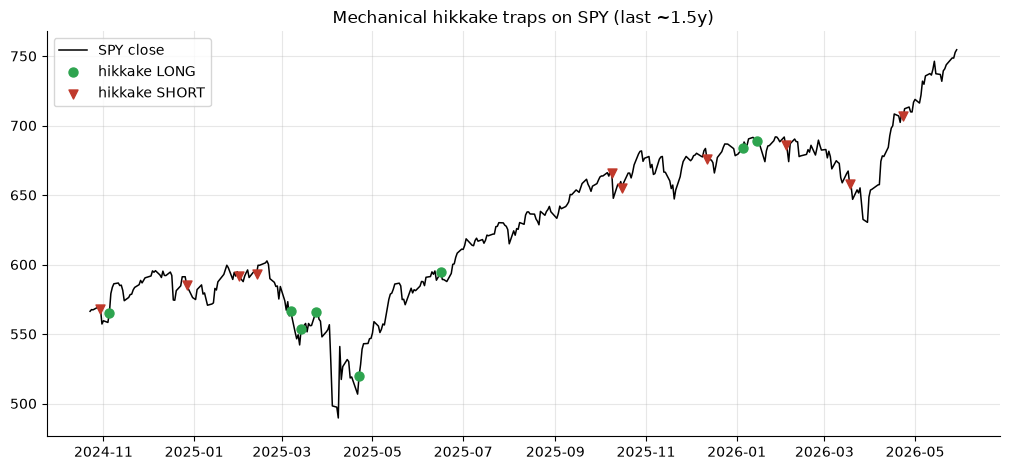

traps in window: 18 | long: 8 short: 10


In [2]:
if HAVE_REAL:
    b = load('SPY'); seg = b.iloc[-400:]
    sig = st.hikkake_signals(b, window=R['window'])
    sig = sig[sig.index >= seg.index[0]]
    longs = sig[sig['dir']>0].index; shorts = sig[sig['dir']<0].index
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.1, label='SPY close')
    ax.scatter(longs, b['close'].reindex(longs), c=GREEN, s=42, zorder=5, label='hikkake LONG')
    ax.scatter(shorts, b['close'].reindex(shorts), c=RED, s=42, zorder=5, marker='v', label='hikkake SHORT')
    ax.set_title('Mechanical hikkake traps on SPY (last ~1.5y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('traps in window:', len(sig), '| long:', len(longs), 'short:', len(shorts))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Plenty of traps, mostly **short** (the inside-bar/fake-out shape fires more often on up-pokes). Now the real test: **race the trap against random entries** at four horizons. Blue = trade the trap; grey = the same trades on random days.

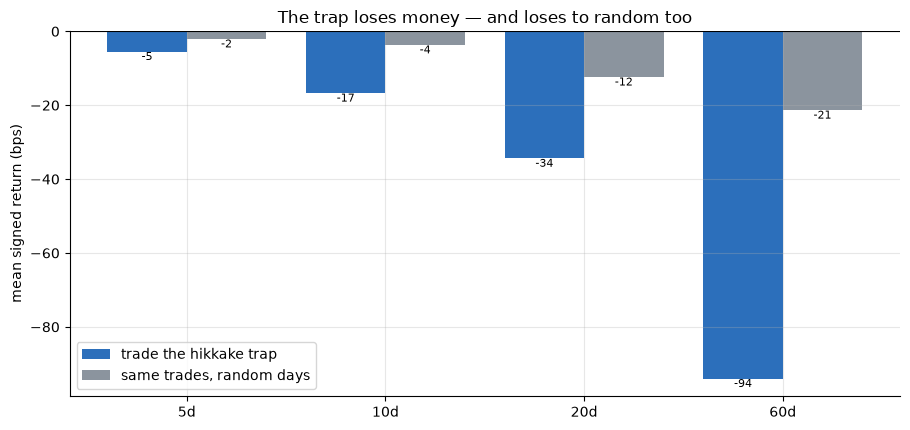

hikkake: [-5, -17, -34, -94]
random: [-2, -4, -12, -21]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    hik, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); sig = st.hikkake_signals(b, window=R['window'])
            rs = st.random_entries(b, sig['dir'].to_numpy(), window=R['window'], seed=7)
            tt.append(st.forward_returns(b, sig, h)); rr.append(st.forward_returns(b, rs, h))
        hik.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    hik = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, hik, .4, color='#2c6fbb', label='trade the hikkake trap')
ax.bar(x+.2, rnd, .4, color=GREY, label='same trades, random days')
ax.axhline(0, c='k', lw=.8)
for i,(a,bb) in enumerate(zip(hik,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top' if a<0 else 'bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='top' if bb<0 else 'bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean signed return (bps)')
ax.set_title('The trap loses money — and loses to random too'); ax.legend()
plt.tight_layout(); plt.show()
print('hikkake:', [round(v) for v in hik]); print('random:', [round(v) for v in rnd])

There's the whole story. The trap's signed return is **negative everywhere** (**-34 bps** at 20 days, **-94** at 60) — and **worse than random** at every horizon. The pattern doesn't forecast the reversal it promises; being short-heavy, it mostly just fades a market that drifts up.

**One more sanity check.** The trap's *only* content is **which way** it predicts. So let's keep every trap date but randomly **flip** each direction. If price really gets trapped, the correctly-directed trade should crush the coin-flip directions.

In [4]:
if HAVE_REAL:
    pl = st.scrambled_direction_placebo(load('SPY'), 20, window=R['window'], n_draws=300, seed=459)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real hikkake (SPY, 20d, correct direction): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *direction-flipped* hikkakes do at least as well (p={pval:.2f}).')
print('=> which way the trap points is NOT doing the work.')

real hikkake (SPY, 20d, correct direction): -53.8 bps
... but 98% of *direction-flipped* hikkakes do at least as well (p=0.98).
=> which way the trap points is NOT doing the work.


**98%** of the **direction-flipped** traps match or beat the real one (*p* = 0.98) — the "correctly" directed trap is among the *worst* coin-flips. If the hikkake genuinely forecast the reversal, flipping it would collapse the result. It doesn't — because the direction was never carrying information.

## 5 · The verdict

- **Signal — None.** The trap's signed return is negative at every horizon and *loses* to the same trades on random days. It does not beat the drift/exposure-matched baseline.
- **Tradability — Mirage.** Negative gross and net; costs only deepen the hole. Nothing to trade.
- **"Does the trap forecast?" — Busted.** Randomly flip which way each trap points and the result is unchanged (*p* = 0.98). The pattern's one piece of content carries no information.

## 6 · Could you actually trade it?

There's nothing here to trade. The trap is negative gross *and* net of costs, it loses to random entries, and its defining direction is a coin flip. A short-heavy rule on an up-drifting market is structurally fighting the tide; you'd do better holding the index and never touching the pattern. As a forecasting tool the hikkake doesn't pay; as a *description* of a fake-out, it was never a strategy.

## 7 · Going further 🚪

- **A trend filter.** Proponents often only take hikkakes *with* the trend. That's adding a *second* rule (and a free parameter); on a drifting tape it mostly re-imports the drift — try it and watch the 'edge' track the filter, not the trap.
- **The confirmation window.** Widening or narrowing the 3-bar window changes the trade count but not the verdict: drift in, trap out.
- **A real positive control.** The quants notebook plants a *genuine* trap-reversal into a synthetic tape and shows the harness banks it (so the dead-flat real result isn't a broken detector — it's an honest 'nothing there').

*Think the trap forecasts? Show the hikkake beating its exposure-matched random baseline at **t ≥ 2** on a real tape — then we'll talk.*